# Task 3 - Spatial Data Mining: Collocation, Clustering & Outlier Analysis

In [1]:

import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import geopandas as gpd
from scipy.stats import gaussian_kde
from scipy.spatial import cKDTree, distance
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#cccccc', 'axes.labelcolor': 'black',
    'xtick.color': 'black', 'ytick.color': 'black',
    'grid.color': '#dddddd', 'text.color': 'black',
    'figure.dpi': 120, 'axes.titlesize': 13, 'axes.titleweight': 'bold'
})
os.makedirs('spatial_data_mining', exist_ok=True)

_WORLD_DATA = None

def get_world_map():
    global _WORLD_DATA
    if _WORLD_DATA is None:
        print("Downloading base map... (This happens only once)")
        try:
            # We use a smaller, faster dataset
            url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
            _WORLD_DATA = gpd.read_file(url)
        except Exception as e:
            print(f"Map download failed: {e}")
            _WORLD_DATA = gpd.GeoDataFrame()
    return _WORLD_DATA

def add_world_map(ax, ocean='#ffffff', land='#f0f0e8', border='#777777'):
    ax.set_facecolor(ocean)
    world = get_world_map()
    if not world.empty:
        # We plot the map as a static background
        world.plot(ax=ax, color=land, edgecolor=border, linewidth=0.3, zorder=1)
    ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
    ax.grid(False)


In [2]:

df = pd.read_csv('spatial_features_engineered.csv', low_memory=False)
print("Loaded engineered features ")


df = df.reset_index(drop=True)
print(f"Shape: {df.shape}")
print(df[['latitude','longitude','depth','mag']].describe())


Loaded engineered features 
Shape: (175946, 57)
            latitude      longitude          depth            mag
count  175946.000000  175946.000000  175946.000000  175946.000000
mean        0.721828      41.967237      64.541041       4.829119
std        29.272740     121.102628     112.598867       0.386124
min       -84.133000    -179.999700      -2.261000       4.500000
25%       -19.997225     -70.880300      10.000000       4.600000
50%        -3.112000      98.631950      30.000000       4.700000
75%        23.704675     142.379950      57.200000       5.000000
max        87.386000     180.000000     700.900000       9.100000


In [3]:

#  SPATIAL CLUSTERING 1: DBSCAN (lat, lon, depth) 
from sklearn.preprocessing import MinMaxScaler

samp = df.sample(min(40000, len(df)), random_state=42).copy()
coords_3d = samp[['latitude','longitude','depth']].values
scaler = MinMaxScaler()
coords_sc = scaler.fit_transform(coords_3d)

db = DBSCAN(eps=0.025, min_samples=8, algorithm='ball_tree', metric='euclidean')
samp['dbscan_label'] = db.fit_predict(coords_sc)

n_clusters = len(set(samp['dbscan_label'])) - (1 if -1 in samp['dbscan_label'].values else 0)
n_noise    = (samp['dbscan_label'] == -1).sum()
print(f"DBSCAN → {n_clusters} clusters, {n_noise} noise points")
print(samp['dbscan_label'].value_counts().head(10))


DBSCAN → 22 clusters, 591 noise points
dbscan_label
 0     33360
 1      4854
-1       591
 5       306
 2       257
 7       192
 9        86
 8        75
 6        61
 12       33
Name: count, dtype: int64


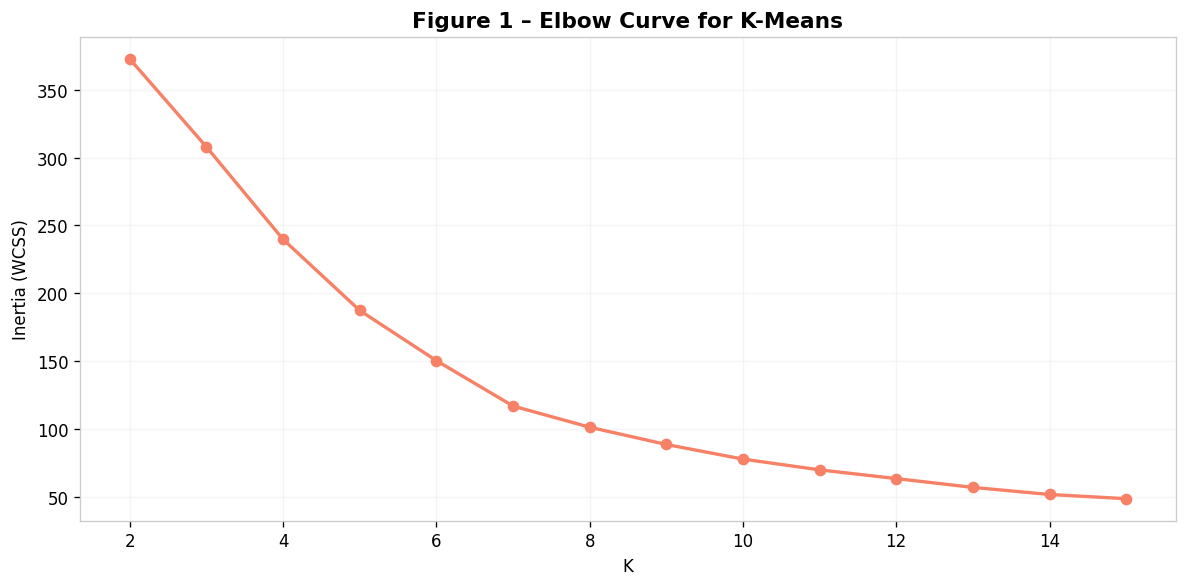

In [4]:
# VIZ 1 – Elbow Curve for K-Means
inertias = []
ks = range(2,16)
samp_small = samp.sample(5000, random_state=0)
X_small = scaler.transform(samp_small[['latitude','longitude','depth']].values)
for k in ks:
    km_t = KMeans(n_clusters=k, random_state=42, n_init=5)
    km_t.fit(X_small)
    inertias.append(km_t.inertia_)
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(ks, inertias, 'o-', color='#f78166', lw=2)
ax.set_xlabel('K'); ax.set_ylabel('Inertia (WCSS)')
ax.set_title('Figure 1 – Elbow Curve for K-Means')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('spatial_data_mining/fig01_elbow.png', dpi=150, bbox_inches='tight')
plt.show()



K-Means labels assigned 
kmeans_label
0    14755
5     9668
1     5040
3     4284
2     4269
4     1155
6      829
Name: count, dtype: int64


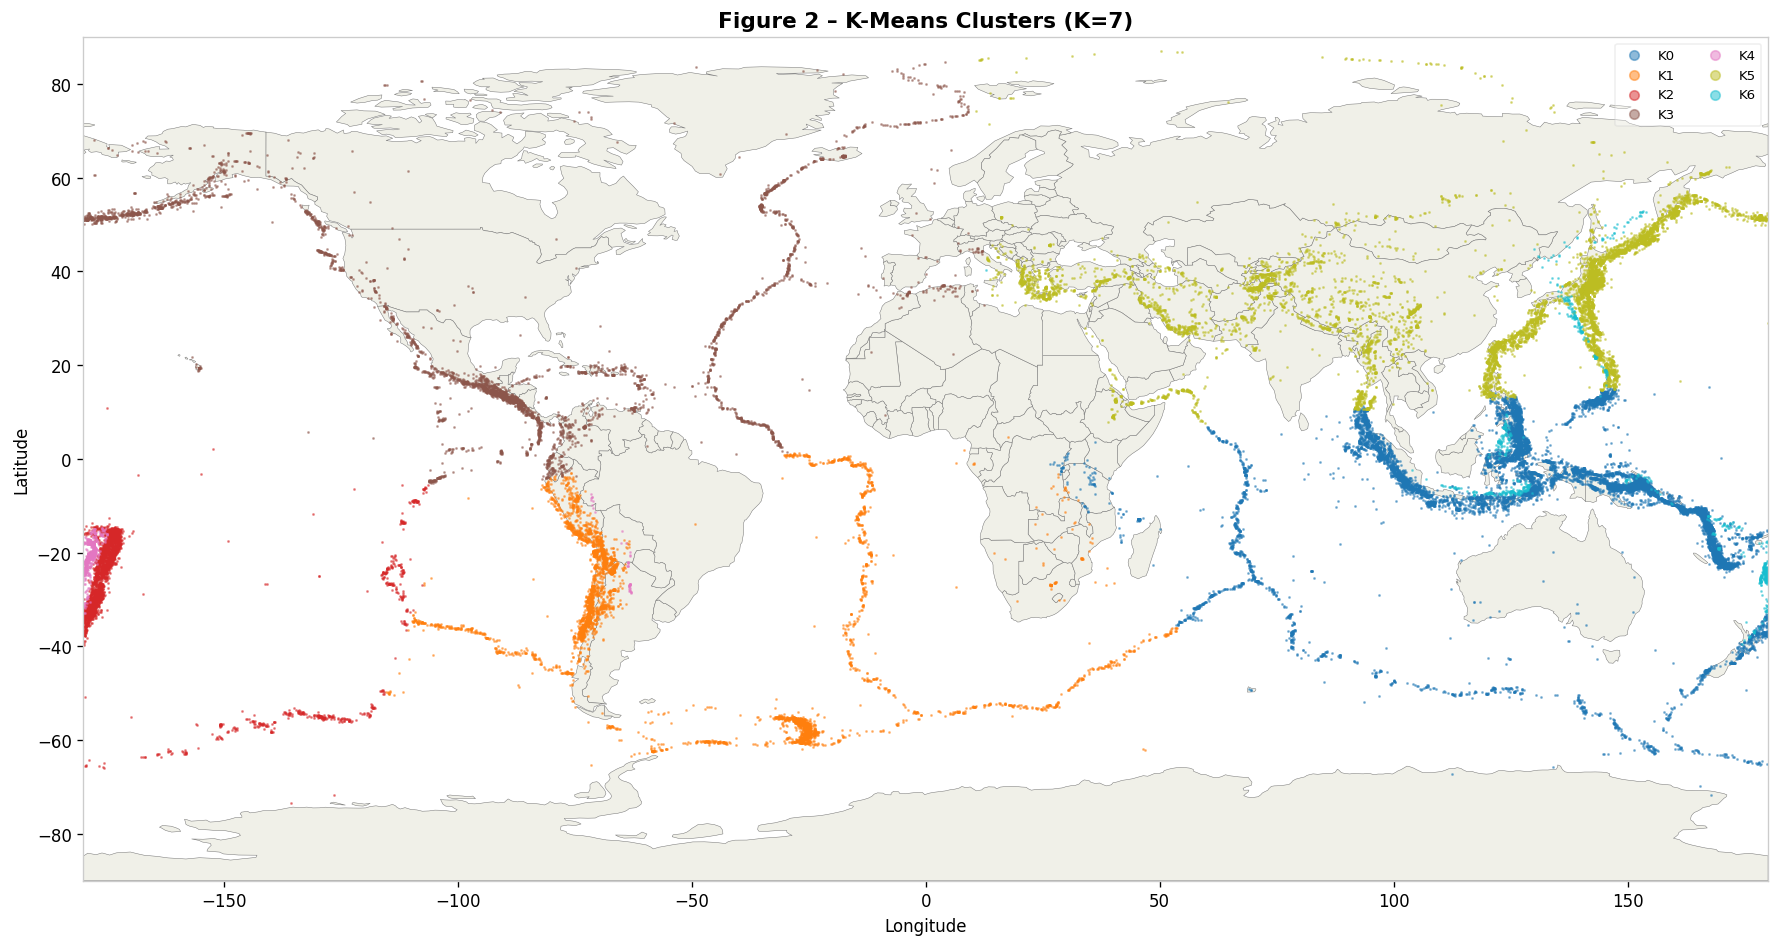

In [5]:

#  SPATIAL CLUSTERING 2: K-Means 
from sklearn.cluster import KMeans

K = 7
km = KMeans(n_clusters=K, random_state=42, n_init=10)
samp['kmeans_label'] = km.fit_predict(scaler.transform(samp[['latitude','longitude','depth']].values))
print("K-Means labels assigned ")
print(samp['kmeans_label'].value_counts())

# VIZ 2 – K-Means Clusters
cmap_km = plt.cm.get_cmap('tab10', K)
fig, ax = plt.subplots(figsize=(16,8))
add_world_map(ax)
for k in range(K):
    sub = samp[samp['kmeans_label'] == k]
    ax.scatter(sub['longitude'], sub['latitude'],
               c=[cmap_km(k)], s=0.5, alpha=0.5, label=f'K{k}')
ax.legend(markerscale=8, framealpha=0.3, fontsize=8, ncol=2)
ax.set_title(f'Figure 2 – K-Means Clusters (K={K})')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('spatial_data_mining/fig02_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:

#  SPATIAL CLUSTERING 3: Gaussian Mixture Model ──
from sklearn.mixture import GaussianMixture

samp2d = samp[['latitude','longitude']].values
sc2 = StandardScaler()
samp2d_sc = sc2.fit_transform(samp2d)
gmm = GaussianMixture(n_components=8, random_state=42, covariance_type='full')
samp['gmm_label'] = gmm.fit_predict(samp2d_sc)
print("GMM labels assigned ")
print(samp['gmm_label'].value_counts())


GMM labels assigned 
gmm_label
5    13350
3     4988
1     4873
7     4703
0     4697
6     2616
2     2556
4     2217
Name: count, dtype: int64


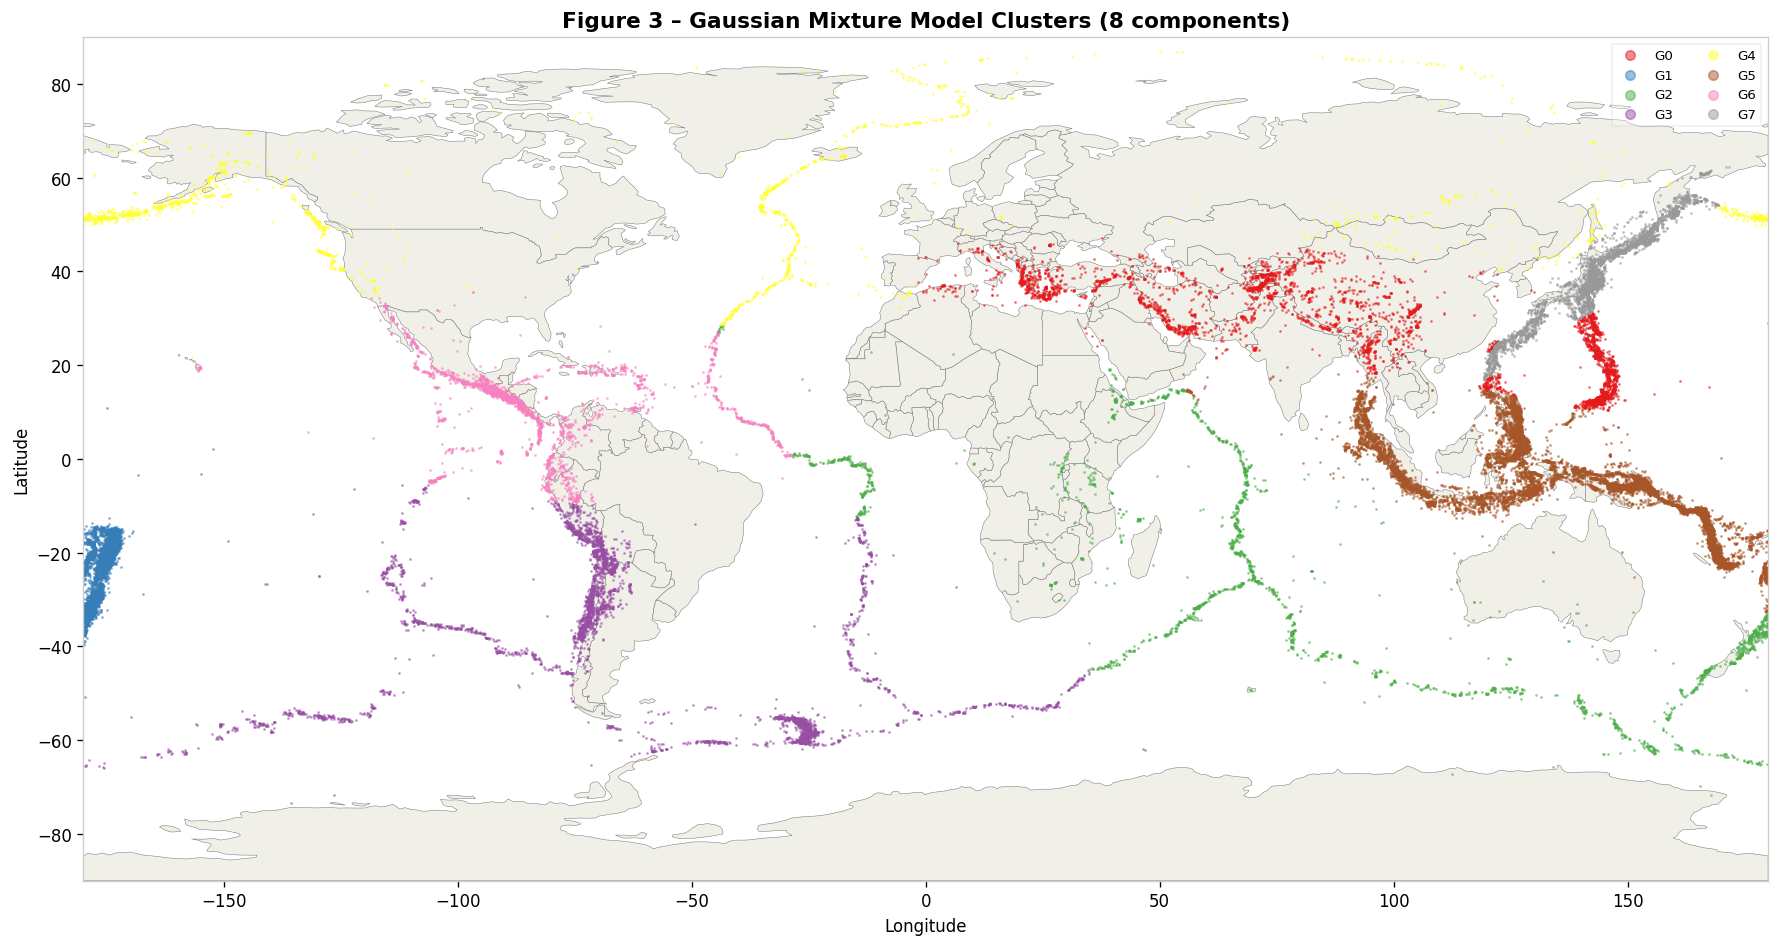

In [7]:

# VIZ 3 – GMM Soft Clustering
cmap_gmm = plt.cm.get_cmap('Set1', 8)
fig, ax = plt.subplots(figsize=(16,8))
add_world_map(ax)
for g in range(8):
    sub = samp[samp['gmm_label'] == g]
    ax.scatter(sub['longitude'], sub['latitude'],
               c=[cmap_gmm(g)], s=0.5, alpha=0.5, label=f'G{g}')
ax.legend(markerscale=8, framealpha=0.3, fontsize=8, ncol=2)
ax.set_title('Figure 3 – Gaussian Mixture Model Clusters (8 components)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('spatial_data_mining/fig03_gmm.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:

#  SPATIAL OUTLIER DETECTION 1: Spatial Z-Score ──
# Z_s(x) = (f(x) - mean_neighbours) / std_neighbours
samp3 = df.sample(min(30000, len(df)), random_state=99).copy()
coords = np.radians(samp3[['latitude','longitude']].values)
tree_out = cKDTree(coords)
# k=9 neighbours
dists_o, idxs_o = tree_out.query(coords, k=10)

nbr_means = np.array([samp3['mag'].values[idxs_o[i,1:]].mean() for i in range(len(samp3))])
nbr_stds  = np.array([samp3['mag'].values[idxs_o[i,1:]].std()+1e-6 for i in range(len(samp3))])
samp3['spatial_Zscore'] = (samp3['mag'].values - nbr_means) / nbr_stds

THRESH = 2.0
outliers = samp3[np.abs(samp3['spatial_Zscore']) > THRESH]
print(f"Spatial outliers (|Zs|>{THRESH}): {len(outliers)} events")
print(outliers['spatial_Zscore'].describe())


Spatial outliers (|Zs|>2.0): 2996 events
count    2996.000000
mean        3.827797
std         2.946330
min        -4.274505
25%         2.377254
50%         3.149783
75%         4.530375
max        30.999535
Name: spatial_Zscore, dtype: float64


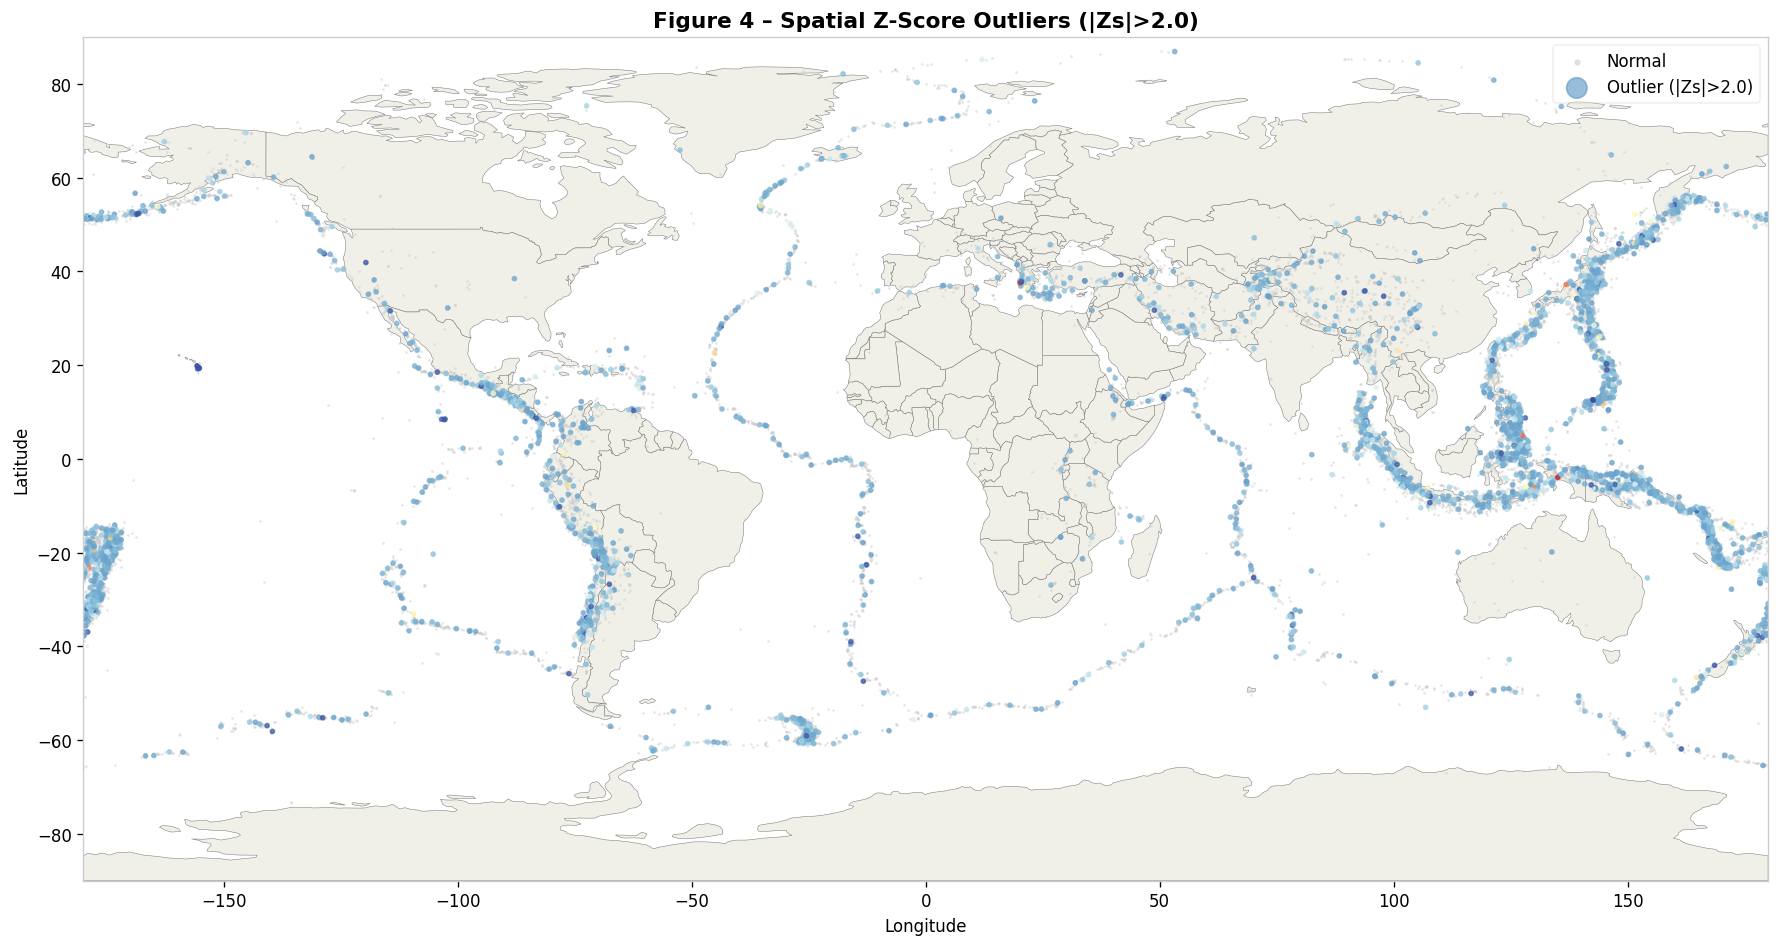

In [9]:

# VIZ 4 – Spatial Z-Score Outlier Map
fig, ax = plt.subplots(figsize=(16,8))
add_world_map(ax)
ax.scatter(samp3['longitude'], samp3['latitude'],
           c='#cccccc', s=0.3, alpha=0.5, label='Normal')
ax.scatter(outliers['longitude'], outliers['latitude'],
           c=outliers['spatial_Zscore'], cmap='RdYlBu_r',
           s=6, alpha=0.7, label=f'Outlier (|Zs|>{THRESH})')
ax.legend(markerscale=5, framealpha=0.3)
ax.set_title(f'Figure 4 – Spatial Z-Score Outliers (|Zs|>{THRESH})')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('spatial_data_mining/fig04_spatial_Zscore.png', dpi=150, bbox_inches='tight')
plt.show()


Moran's I = 0.0444


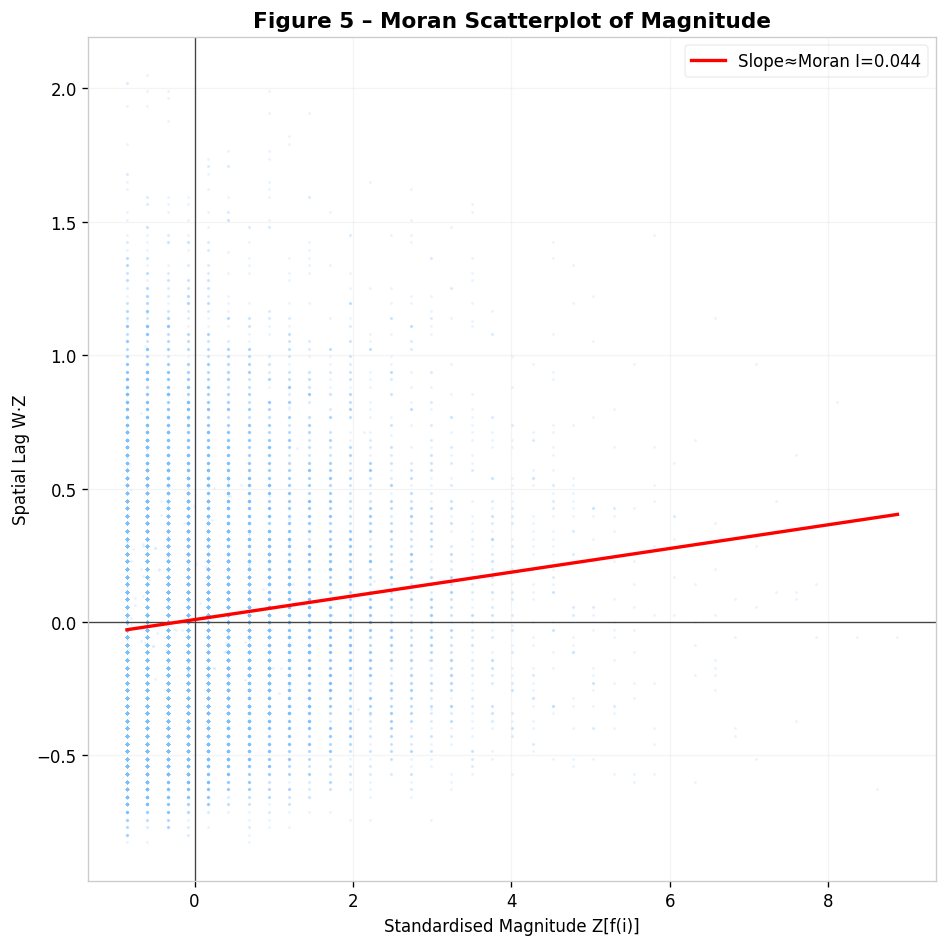

In [10]:

# VIZ 5 – Moran Scatterplot
mag_sub = samp3['mag'].values
mag_z = (mag_sub - mag_sub.mean()) / mag_sub.std()
# spatial lag (row-normalised weight matrix via kNN)
W_mag = np.array([mag_z[idxs_o[i,1:]].mean() for i in range(len(samp3))])
# Moran's I
I = (mag_z * W_mag).sum() / (mag_z**2).sum()
print(f"Moran's I = {I:.4f}")

fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(mag_z, W_mag, alpha=0.1, s=1, c='#79c0ff')
# quadrant lines
ax.axhline(0, color='#444444', lw=0.8); ax.axvline(0, color='#444444', lw=0.8)
# regression line
m, b = np.polyfit(mag_z, W_mag, 1)
x_r = np.linspace(mag_z.min(), mag_z.max(), 100)
ax.plot(x_r, m*x_r+b, 'r-', lw=2, label=f"Slope≈Moran I={I:.3f}")
ax.set_xlabel('Standardised Magnitude Z[f(i)]')
ax.set_ylabel('Spatial Lag W·Z')
ax.set_title("Figure 5 – Moran Scatterplot of Magnitude")
ax.legend(framealpha=0.3); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('spatial_data_mining/fig05_moran.png', dpi=150, bbox_inches='tight')
plt.show()


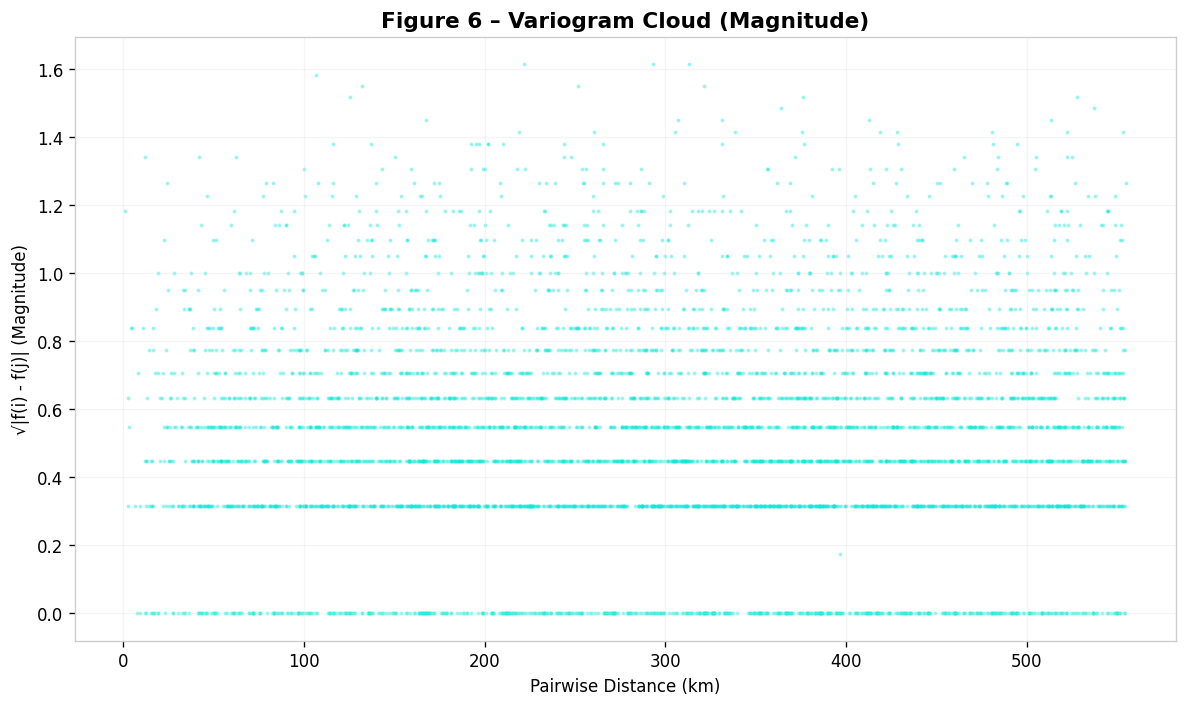

In [11]:

# VIZ 6 – Variogram Cloud (subset 3000 events for clarity)
sub_v = samp3.sample(3000, random_state=5).reset_index(drop=True)
pairs_i, pairs_j = [], []
coords_v = np.radians(sub_v[['latitude','longitude']].values)
tree_v = cKDTree(coords_v)
# only event pairs within 5° (≈555 km)
pairs_list = tree_v.query_pairs(r=np.radians(5))
pairs_list = list(pairs_list)[:5000]

dist_pairs = [np.degrees(distance.euclidean(coords_v[i], coords_v[j]))*111 for i,j in pairs_list]
diff_pairs = [np.sqrt(abs(sub_v.loc[i,'mag'] - sub_v.loc[j,'mag'])) for i,j in pairs_list]

fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(dist_pairs, diff_pairs, alpha=0.3, s=2, c="#0fe9d7")
ax.set_xlabel('Pairwise Distance (km)')
ax.set_ylabel('√|f(i) - f(j)| (Magnitude)')
ax.set_title('Figure 6 – Variogram Cloud (Magnitude)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('spatial_data_mining/fig06_variogram.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:

# COLLOCATION ANALYSIS
# Define Boolean spatial features for collocation:
# Feature A: High magnitude event (mag >= 6.5) – "HiMag"
# Feature B: Shallow depth (< 70 km)           – "Shallow"
# Feature C: Very deep (>= 400 km)             – "VDeep"
# Feature D: Intermediate mag (5.5 - 6.5)      – "MidMag"

df['feat_HiMag']   = df['mag']   >= 6.5
df['feat_Shallow'] = df['depth'] <  70
df['feat_VDeep']   = df['depth'] >= 400
df['feat_MidMag']  = (df['mag'] >= 5.5) & (df['mag'] < 6.5)

print("Feature prevalence:")
for f in ['feat_HiMag','feat_Shallow','feat_VDeep','feat_MidMag']:
    print(f"  {f}: {df[f].sum()} events ({100*df[f].mean():.1f}%)")


Feature prevalence:
  feat_HiMag: 1156 events (0.7%)
  feat_Shallow: 138861 events (78.9%)
  feat_VDeep: 7121 events (4.0%)
  feat_MidMag: 11354 events (6.5%)


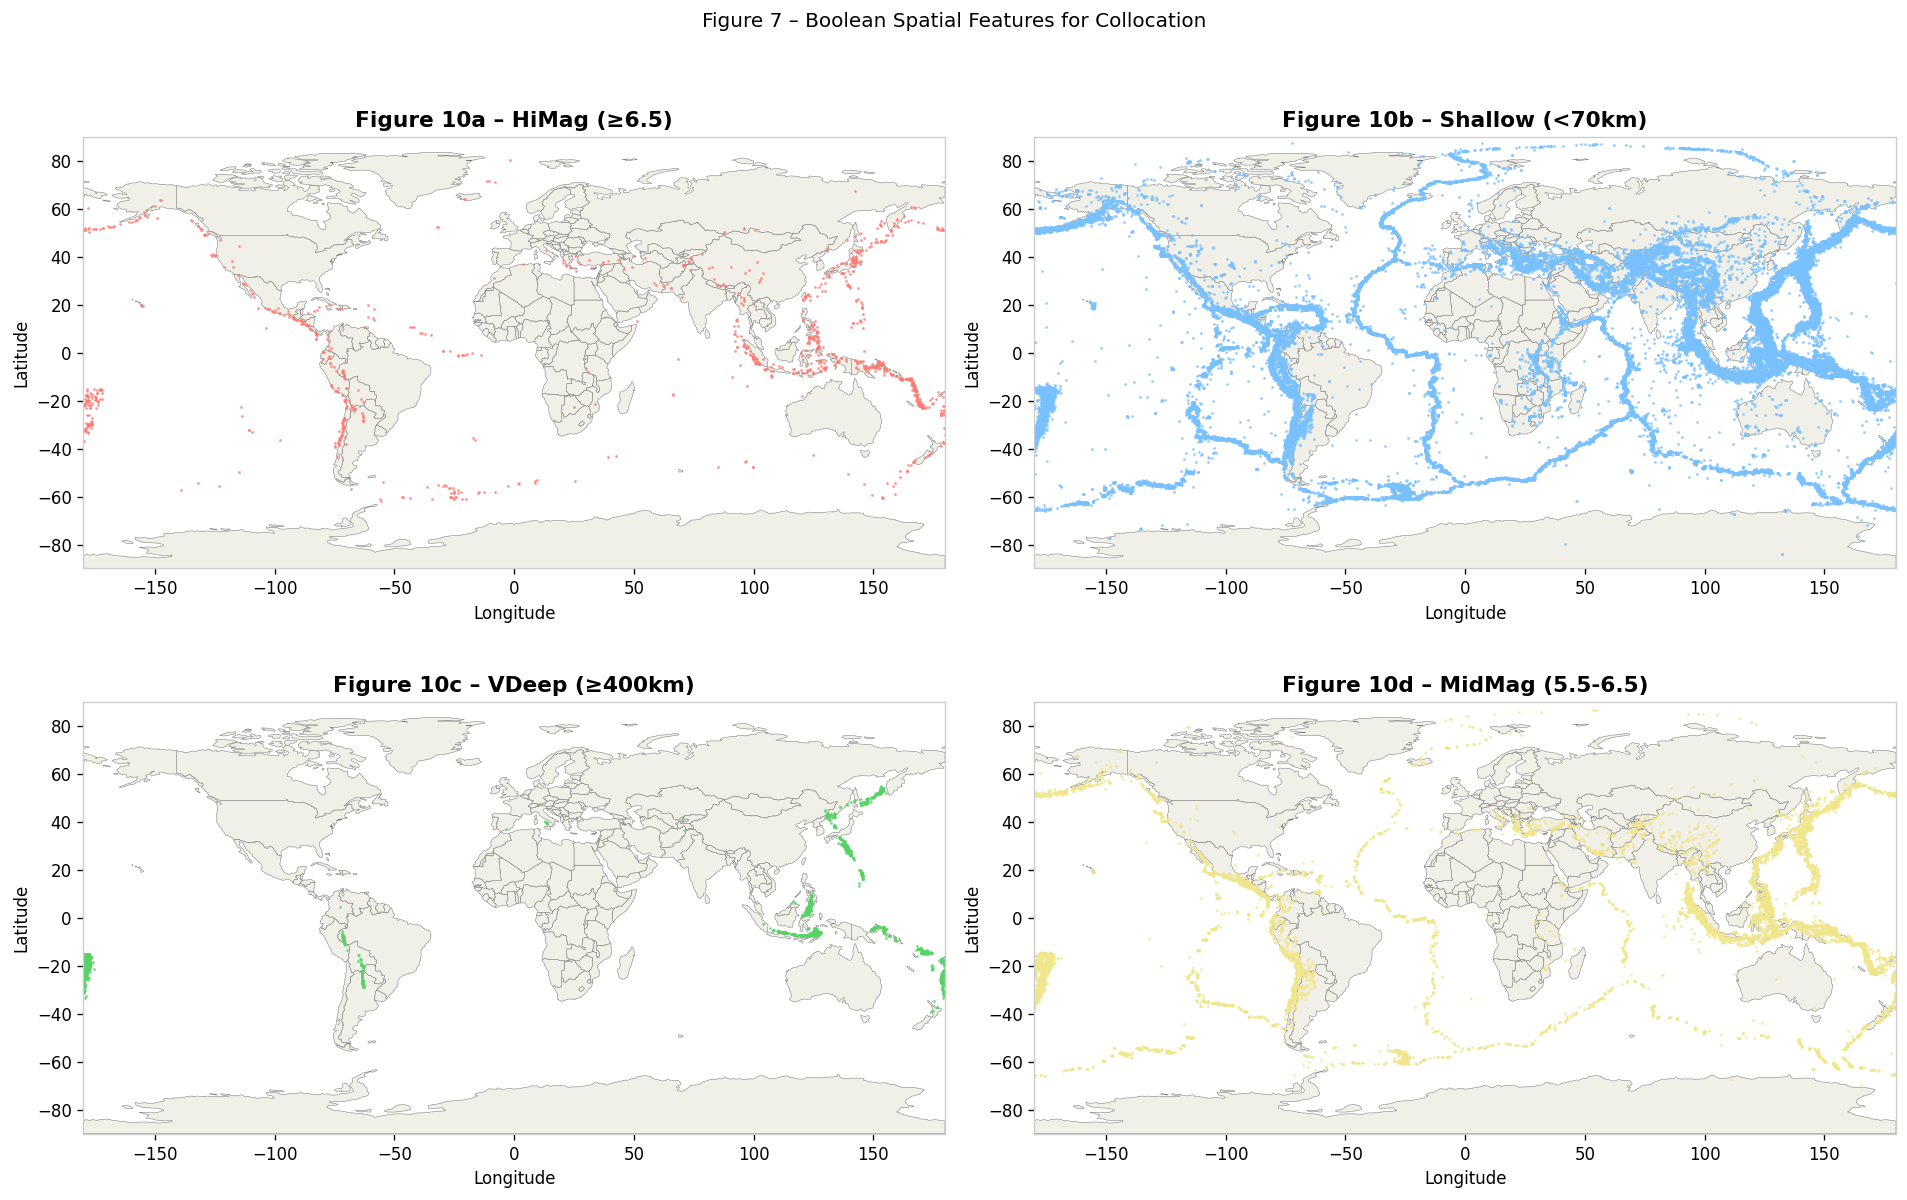

In [13]:

# VIZ 7 – Boolean Feature Maps (4-panel)
feat_c = {'feat_HiMag':'#ff7b72','feat_Shallow':'#79c0ff',
          'feat_VDeep':'#56d364','feat_MidMag':'#f0e68c'}
feat_l = {'feat_HiMag':'HiMag (≥6.5)','feat_Shallow':'Shallow (<70km)',
          'feat_VDeep':'VDeep (≥400km)','feat_MidMag':'MidMag (5.5-6.5)'}

fig, axes = plt.subplots(2, 2, figsize=(16,10))
axes = axes.flatten()
for i, (feat, col) in enumerate(feat_c.items()):
    sub_f = df[df[feat]]
    add_world_map(axes[i])
    axes[i].scatter(sub_f['longitude'], sub_f['latitude'],
                    c=col, s=0.5, alpha=0.7)
    axes[i].set_title(f'Figure 10{chr(97+i)} – {feat_l[feat]}')
    axes[i].set_xlabel('Longitude'); axes[i].set_ylabel('Latitude')
plt.suptitle('Figure 7 – Boolean Spatial Features for Collocation', y=1.01)
plt.tight_layout()
plt.savefig('spatial_data_mining/fig07_bool_features.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:

#  EVENT-CENTRIC COLLOCATION (neighbourhood radius = 1°) 
RADIUS_DEG = 1.0
all_coords_r = np.radians(df[['latitude','longitude']].values)
tree_all = cKDTree(all_coords_r)

# For each HiMag event find fraction of Shallow events in neighbourhood
hi_idx  = df.index[df['feat_HiMag']].tolist()
sh_idx  = set(df.index[df['feat_Shallow']].tolist())
vd_idx  = set(df.index[df['feat_VDeep']].tolist())
md_idx  = set(df.index[df['feat_MidMag']].tolist())

# participation index
def participation_ratio(A_indices, B_indices_set, radius_rad, tree, n_total):
    count_A_with_B = 0
    for ai in A_indices:
        nbrs = tree.query_ball_point(all_coords_r[ai], r=radius_rad)
        nbrs_set = set(nbrs) - {ai}
        if nbrs_set & B_indices_set:
            count_A_with_B += 1
    return count_A_with_B / max(len(A_indices), 1)

r_rad = np.radians(RADIUS_DEG)
# Use a sample of HiMag events for speed
hi_samp = hi_idx[:2000]

pr_HiMag_Shallow = participation_ratio(hi_samp, sh_idx, r_rad, tree_all, len(df))
pr_HiMag_VDeep   = participation_ratio(hi_samp, vd_idx, r_rad, tree_all, len(df))
pr_HiMag_MidMag  = participation_ratio(hi_samp, md_idx, r_rad, tree_all, len(df))

print(f"P(Shallow in nbr | HiMag) = {pr_HiMag_Shallow:.3f}")
print(f"P(VDeep  in nbr | HiMag) = {pr_HiMag_VDeep:.3f}")
print(f"P(MidMag in nbr | HiMag) = {pr_HiMag_MidMag:.3f}")


P(Shallow in nbr | HiMag) = 0.958
P(VDeep  in nbr | HiMag) = 0.198
P(MidMag in nbr | HiMag) = 0.958


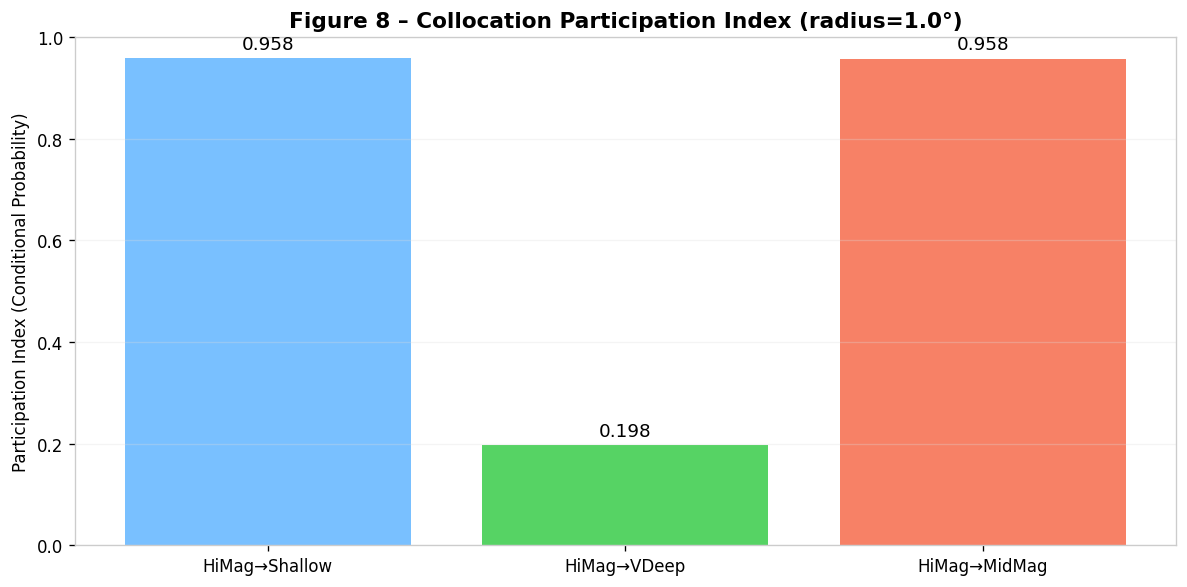

In [15]:

# VIZ 8 – Collocation Rule Participation Index
labels_coll = ['HiMag→Shallow','HiMag→VDeep','HiMag→MidMag']
values_coll = [pr_HiMag_Shallow, pr_HiMag_VDeep, pr_HiMag_MidMag]
fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(labels_coll, values_coll, color=['#79c0ff','#56d364','#f78166'])
for bar, val in zip(bars, values_coll):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}',
            ha='center', va='bottom', fontsize=11)
ax.set_ylim(0,1); ax.set_ylabel('Participation Index (Conditional Probability)')
ax.set_title(f'Figure 8 – Collocation Participation Index (radius={RADIUS_DEG}°)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('spatial_data_mining/fig08_collocation_bar.png', dpi=150, bbox_inches='tight')
plt.show()


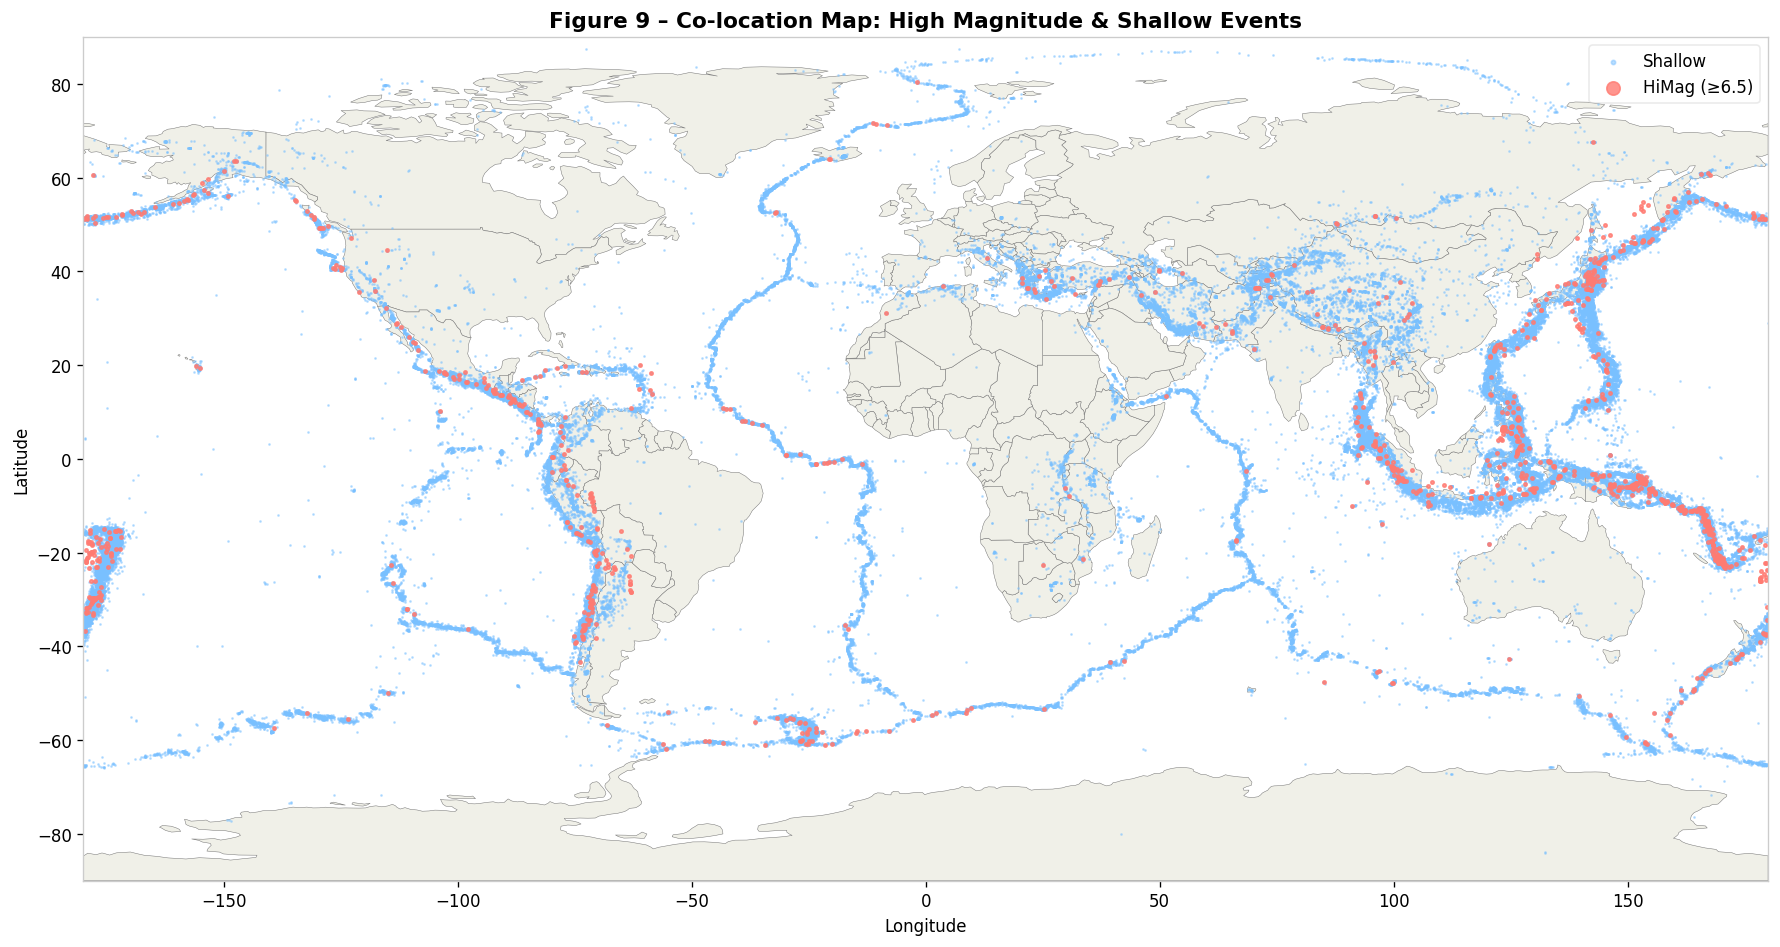

In [16]:

# VIZ 9 – Co-location Map: HiMag & Shallow
hi_df = df[df['feat_HiMag']]
sh_df = df[df['feat_Shallow']]
fig, ax = plt.subplots(figsize=(16,8))
add_world_map(ax)
ax.scatter(sh_df['longitude'], sh_df['latitude'],
           c='#79c0ff', s=0.4, alpha=0.5, label='Shallow')
ax.scatter(hi_df['longitude'], hi_df['latitude'],
           c='#ff7b72', s=4, alpha=0.8, label='HiMag (≥6.5)')
ax.legend(markerscale=4, framealpha=0.4)
ax.set_title('Figure 9 – Co-location Map: High Magnitude & Shallow Events')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('spatial_data_mining/fig09_colocation_map.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:

# POINT PATTERN ANALYSIS: Ripley's K & L Function
# Compute empirical K(t) and compare with CSR (K_csr = π t²)
# Work on a 2-D projection; use sample

def ripleys_K(coords_deg, radii_km, area_km2):
    """Simple Ripley K estimator."""
    n = len(coords_deg)
    if n < 2: return np.zeros(len(radii_km))
    # convert to approx km (equirectangular)
    lat0 = coords_deg[:,0].mean()
    scale_lat = 111.0
    scale_lon = 111.0 * np.cos(np.radians(lat0))
    pts_km = np.column_stack([coords_deg[:,0]*scale_lat,
                               coords_deg[:,1]*scale_lon])
    K_vals = []
    from scipy.spatial import cKDTree
    tree_k = cKDTree(pts_km)
    for r in radii_km:
        pairs = tree_k.query_pairs(r)
        K_vals.append( (2 * len(pairs) / n) * (area_km2 / n) )
    return np.array(K_vals)

# Focus on Pacific Ring of Fire region 
roi = df[(df['latitude'].between(20,60)) & (df['longitude'].between(120,180))]
roi = roi.sample(min(5000, len(roi)), random_state=0)
area = (60-20)*(180-120) * (111**2)  

radii = np.linspace(50, 1000, 20)
K_obs = ripleys_K(roi[['latitude','longitude']].values, radii, area)
K_csr = np.pi * radii**2

print(f"K(t=500km) observed: {K_obs[9]:.2e}")
print(f"K(t=500km) CSR:      {K_csr[9]:.2e}")
print("Ratio:", K_obs[9]/K_csr[9])


K(t=500km) observed: 4.85e+06
K(t=500km) CSR:      7.85e+05
Ratio: 6.172829034206208


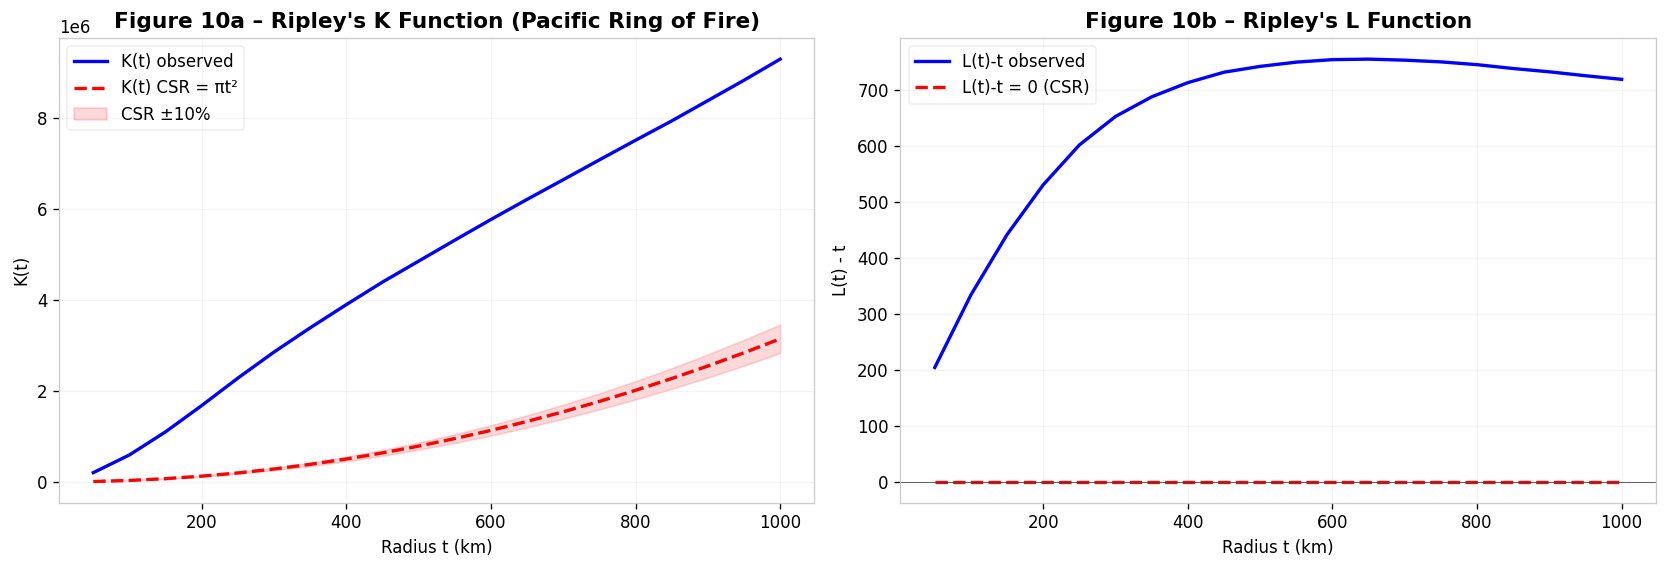

In [18]:

# VIZ 10 – Ripley's K and L Functions
L_obs = np.sqrt(K_obs / np.pi) - radii
L_csr = np.zeros_like(radii)

fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].plot(radii, K_obs, 'b-', lw=2, label='K(t) observed')
axes[0].plot(radii, K_csr, 'r--', lw=2, label='K(t) CSR = πt²')
axes[0].fill_between(radii, K_csr*0.9, K_csr*1.1, alpha=0.15, color='red', label='CSR ±10%')
axes[0].set_xlabel('Radius t (km)'); axes[0].set_ylabel("K(t)")
axes[0].set_title("Figure 10a – Ripley's K Function (Pacific Ring of Fire)")
axes[0].legend(framealpha=0.3); axes[0].grid(alpha=0.3)

axes[1].plot(radii, L_obs, 'b-', lw=2, label='L(t)-t observed')
axes[1].plot(radii, L_csr, 'r--', lw=2, label='L(t)-t = 0 (CSR)')
axes[1].axhline(0, color='#444444', lw=0.5)
axes[1].set_xlabel('Radius t (km)'); axes[1].set_ylabel("L(t) - t")
axes[1].set_title("Figure 10b – Ripley's L Function")
axes[1].legend(framealpha=0.3); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('spatial_data_mining/fig10_ripley.png', dpi=150, bbox_inches='tight')
plt.show()


Mean NN distance: 12.7 km  |  Expected (CSR): 38.5 km
R = 0.331 → Clustered


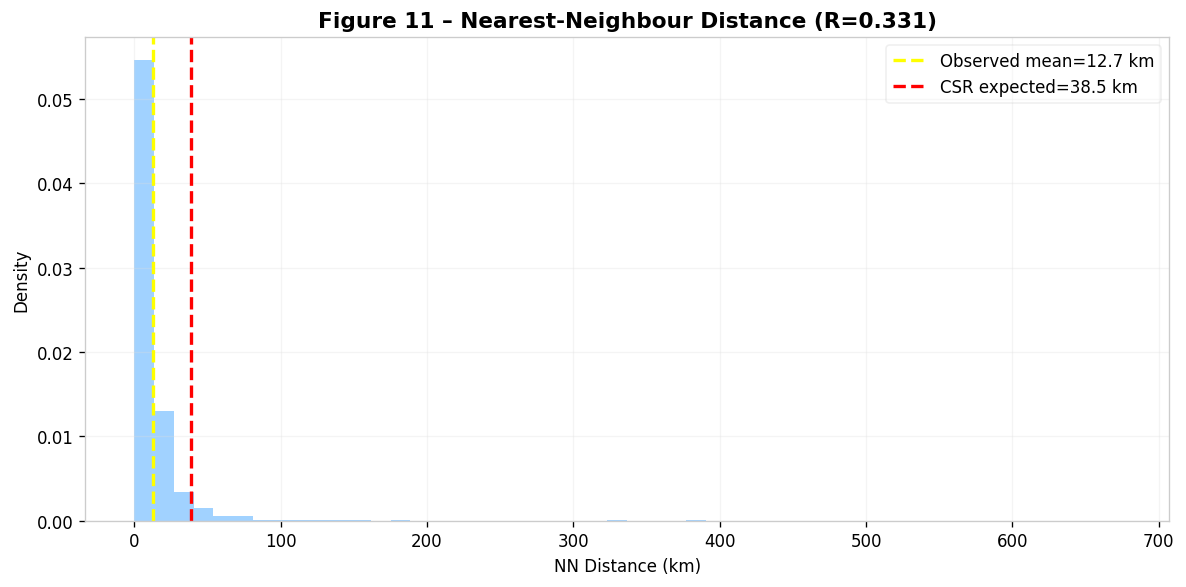

In [19]:

# VIZ 11 – Nearest-Neighbour Analysis (Average NN Distance)
coords_r_roi = np.radians(roi[['latitude','longitude']].values)
tree_nn = cKDTree(coords_r_roi)
nn_dists, _ = tree_nn.query(coords_r_roi, k=2)
nn_km = nn_dists[:,1] * 6371.0

# CSR expected: E[NN] = 0.5 / sqrt(density)
density = len(roi) / area   # events per km²
E_nn = 0.5 / np.sqrt(density)
R = nn_km.mean() / E_nn
print(f"Mean NN distance: {nn_km.mean():.1f} km  |  Expected (CSR): {E_nn:.1f} km")
print(f"R = {R:.3f} → {'Clustered' if R<1 else 'Regular'}")

fig, ax = plt.subplots(figsize=(10,5))
ax.hist(nn_km, bins=50, color='#79c0ff', edgecolor='none', density=True, alpha=0.7)
ax.axvline(nn_km.mean(), color='yellow', lw=2, linestyle='--', label=f'Observed mean={nn_km.mean():.1f} km')
ax.axvline(E_nn, color='red', lw=2, linestyle='--', label=f'CSR expected={E_nn:.1f} km')
ax.set_xlabel('NN Distance (km)'); ax.set_ylabel('Density')
ax.set_title(f'Figure 11 – Nearest-Neighbour Distance (R={R:.3f})')
ax.legend(framealpha=0.3); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('spatial_data_mining/fig11_nna.png', dpi=150, bbox_inches='tight')
plt.show()


Hot spots:  704, Cold spots: 0


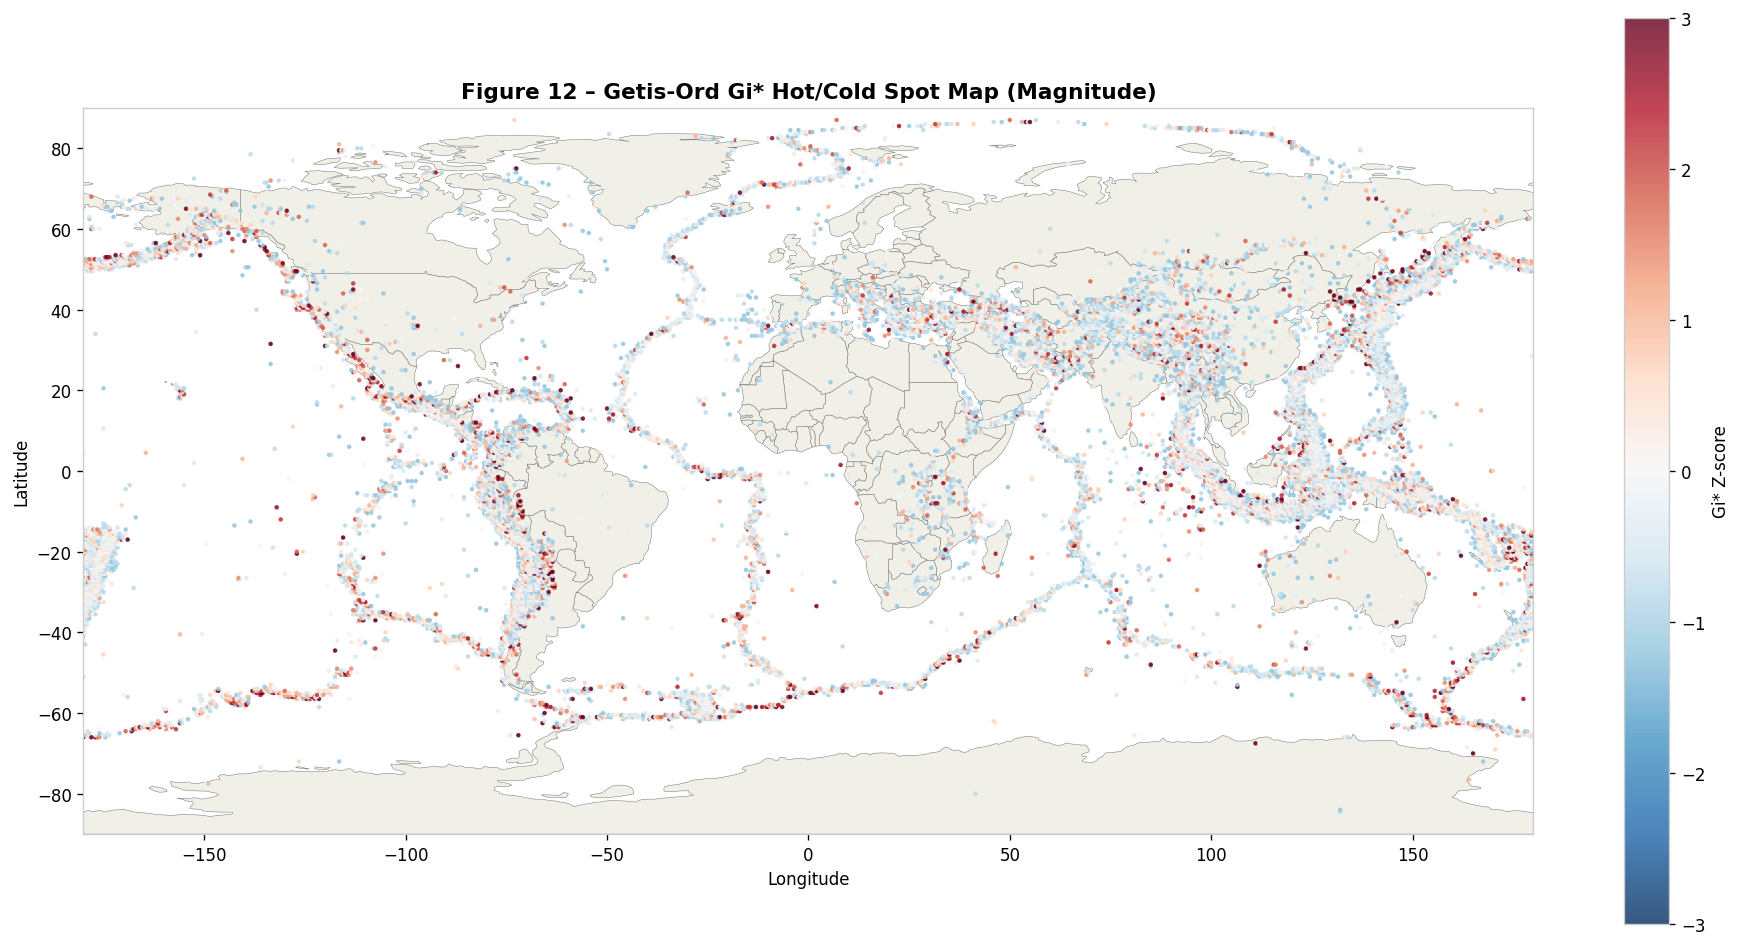

In [20]:

# VIZ 12 – Getis-Ord Gi* Hot/Cold Spot Analysis (grid level)
# Using grid cells from the main df
gc = df.groupby(['grid_lat','grid_lon'])['mag'].agg(['mean','count']).reset_index()
gc.columns = ['grid_lat','grid_lon','mean_mag','count']
gc = gc.dropna()

mag_all = gc['mean_mag'].values
n = len(gc)
global_mean = mag_all.mean()
global_std  = mag_all.std()

# For each cell: Gi* = (sum of weights * values - mean*sum_weights) / std formula
# Simplified: Z-score of local mean vs global
gi_z = (mag_all - global_mean) / (global_std + 1e-9)
gc['gi_z'] = gi_z
hot  = gc[gc['gi_z'] >  1.96]
cold = gc[gc['gi_z'] < -1.96]
print(f"Hot spots:  {len(hot)}, Cold spots: {len(cold)}")

fig, ax = plt.subplots(figsize=(16,8))
add_world_map(ax)
sc = ax.scatter(gc['grid_lon'], gc['grid_lat'], c=gc['gi_z'],
                cmap='RdBu_r', s=3, alpha=0.8, vmin=-3, vmax=3)
fig.colorbar(sc, ax=ax, label='Gi* Z-score')
ax.set_title('Figure 12 – Getis-Ord Gi* Hot/Cold Spot Map (Magnitude)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('spatial_data_mining/fig12_getis_ord.png', dpi=150, bbox_inches='tight')
plt.show()


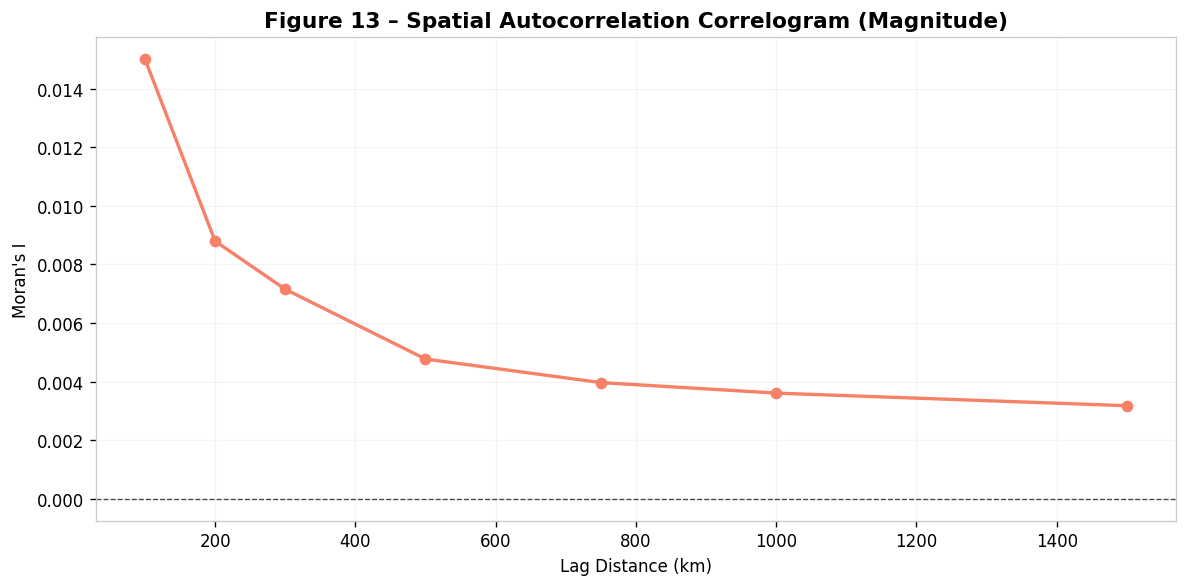

In [21]:

# VIZ 13 – Spatial Autocorrelation Correlogram
# Compute Moran's I for multiple lag distances
lag_kms = [100, 200, 300, 500, 750, 1000, 1500]
samp_ac = samp3.copy()
coords_ac = np.radians(samp_ac[['latitude','longitude']].values)
tree_ac   = cKDTree(coords_ac)
mag_ac    = samp_ac['mag'].values
mag_z_ac  = (mag_ac - mag_ac.mean()) / mag_ac.std()

morans = []
for lkm in lag_kms:
    r_rad = lkm / 6371.0
    # build sparse weight matrix
    pairs_ac = tree_ac.query_pairs(r_rad, output_type='ndarray')
    if len(pairs_ac) == 0:
        morans.append(0.0); continue
    wi_sum = len(pairs_ac)
    cross   = (mag_z_ac[pairs_ac[:,0]] * mag_z_ac[pairs_ac[:,1]]).sum()
    I_l = (len(mag_z_ac) / wi_sum) * cross / (mag_z_ac**2).sum()
    morans.append(I_l)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(lag_kms, morans, 'o-', color='#f78166', lw=2)
ax.axhline(0, color='#444444', lw=0.8, linestyle='--')
ax.set_xlabel('Lag Distance (km)'); ax.set_ylabel("Moran's I")
ax.set_title("Figure 13 – Spatial Autocorrelation Correlogram (Magnitude)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('spatial_data_mining/fig13_correlogram.png', dpi=150, bbox_inches='tight')
plt.show()


HiMag in ROI: 35, Shallow in ROI: 4227


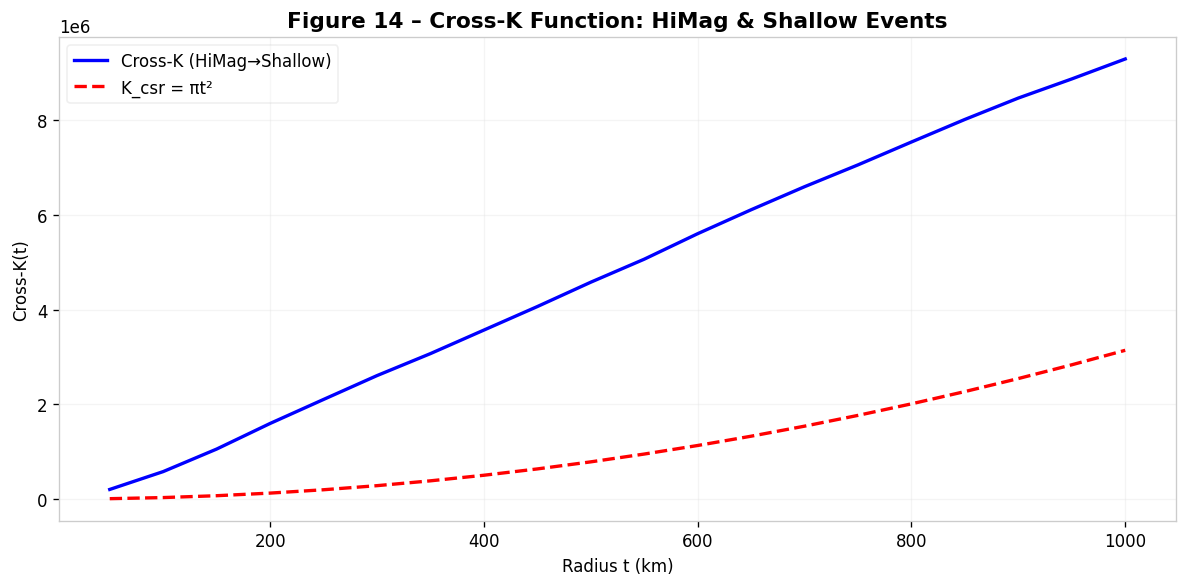

In [22]:

# VIZ 14 – Cross-K Function: HiMag vs Shallow events (Pacific ROI)
roi_hi = roi[roi['feat_HiMag']] if 'feat_HiMag' in roi.columns else          roi[roi['mag'] >= 6.5]
roi_sh = roi[roi['depth'] < 70]
print(f"HiMag in ROI: {len(roi_hi)}, Shallow in ROI: {len(roi_sh)}")

def cross_K(A_coords_deg, B_coords_deg, radii_km, area_km2):
    lat0 = A_coords_deg[:,0].mean()
    sl = 111.0; slo = 111.0*np.cos(np.radians(lat0))
    A_km = np.column_stack([A_coords_deg[:,0]*sl, A_coords_deg[:,1]*slo])
    B_km = np.column_stack([B_coords_deg[:,0]*sl, B_coords_deg[:,1]*slo])
    nA, nB = len(A_km), len(B_km)
    from scipy.spatial import cKDTree
    tree_B = cKDTree(B_km)
    K12 = []
    for r in radii_km:
        cnt = tree_B.query_ball_point(A_km, r, return_length=True)
        K12.append(area_km2 * cnt.sum() / (nA * nB))
    return np.array(K12)

ck = cross_K(roi_hi[['latitude','longitude']].values,
             roi_sh[['latitude','longitude']].values,
             radii, area) if (len(roi_hi) > 0 and len(roi_sh) > 0) else K_csr

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(radii, ck, 'b-', lw=2, label='Cross-K (HiMag→Shallow)')
ax.plot(radii, K_csr, 'r--', lw=2, label='K_csr = πt²')
ax.set_xlabel('Radius t (km)'); ax.set_ylabel('Cross-K(t)')
ax.set_title('Figure 14 – Cross-K Function: HiMag & Shallow Events')
ax.legend(framealpha=0.3); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('spatial_data_mining/fig14_cross_K.png', dpi=150, bbox_inches='tight')
plt.show()


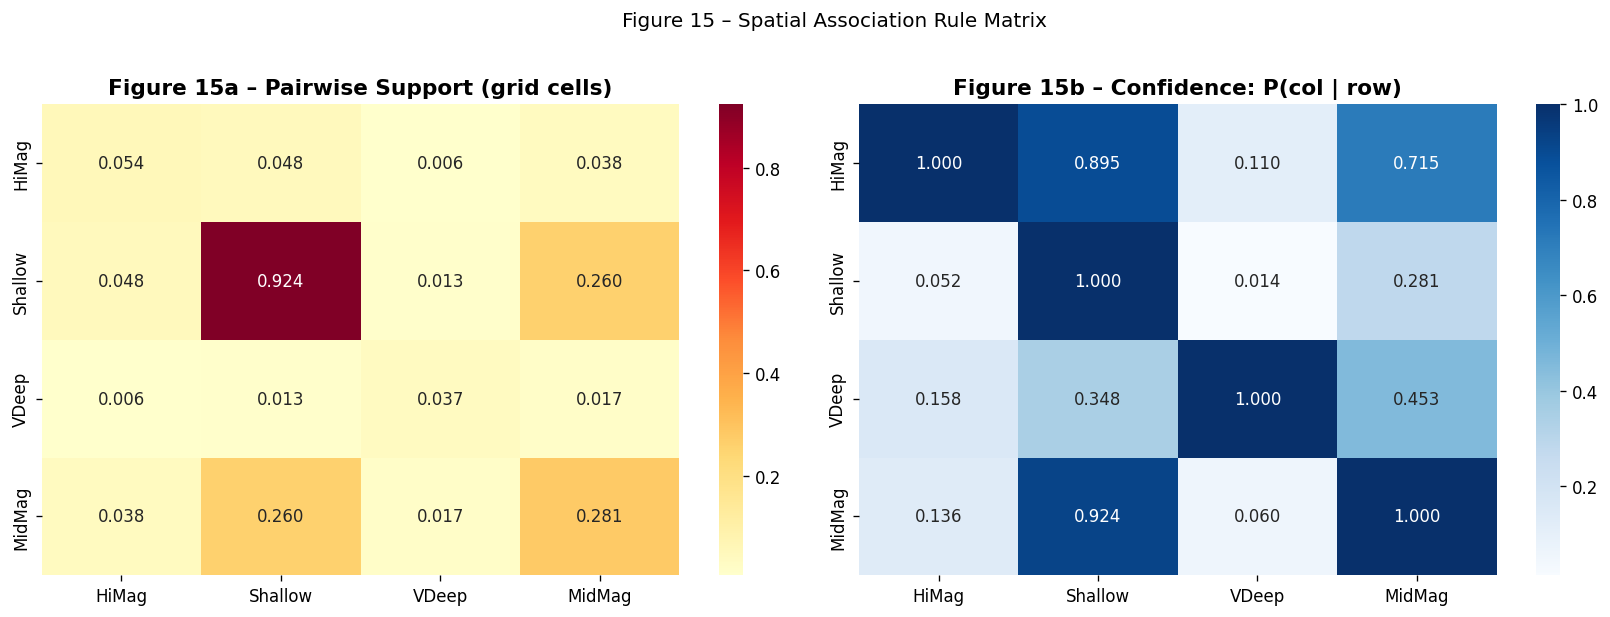

In [23]:

# VIZ 15 – Spatial Association Rules: Support & Confidence Matrix
# Grid-based support: fraction of cells containing both features
grid_feat = df.groupby('grid_cell_id').agg(
    has_HiMag=('feat_HiMag','max'),
    has_Shallow=('feat_Shallow','max'),
    has_VDeep=('feat_VDeep','max'),
    has_MidMag=('feat_MidMag','max')
).reset_index()

feats = ['has_HiMag','has_Shallow','has_VDeep','has_MidMag']
feat_names = ['HiMag','Shallow','VDeep','MidMag']

conf_mat = np.zeros((4,4))
supp_mat = np.zeros((4,4))
n_cells = len(grid_feat)

for i, fi in enumerate(feats):
    for j, fj in enumerate(feats):
        if i == j:
            supp_mat[i,j] = grid_feat[fi].mean()
            conf_mat[i,j] = 1.0
        else:
            supp = (grid_feat[fi] & grid_feat[fj]).mean()
            conf = supp / grid_feat[fi].mean() if grid_feat[fi].mean() > 0 else 0
            supp_mat[i,j] = supp
            conf_mat[i,j] = conf

fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.heatmap(supp_mat, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=feat_names, yticklabels=feat_names, ax=axes[0])
axes[0].set_title('Figure 15a – Pairwise Support (grid cells)')

sns.heatmap(conf_mat, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=feat_names, yticklabels=feat_names, ax=axes[1])
axes[1].set_title('Figure 15b – Confidence: P(col | row)')
plt.suptitle('Figure 15 – Spatial Association Rule Matrix', y=1.02)
plt.tight_layout()
plt.savefig('spatial_data_mining/fig15_assoc_rules.png', dpi=150, bbox_inches='tight')
plt.show()


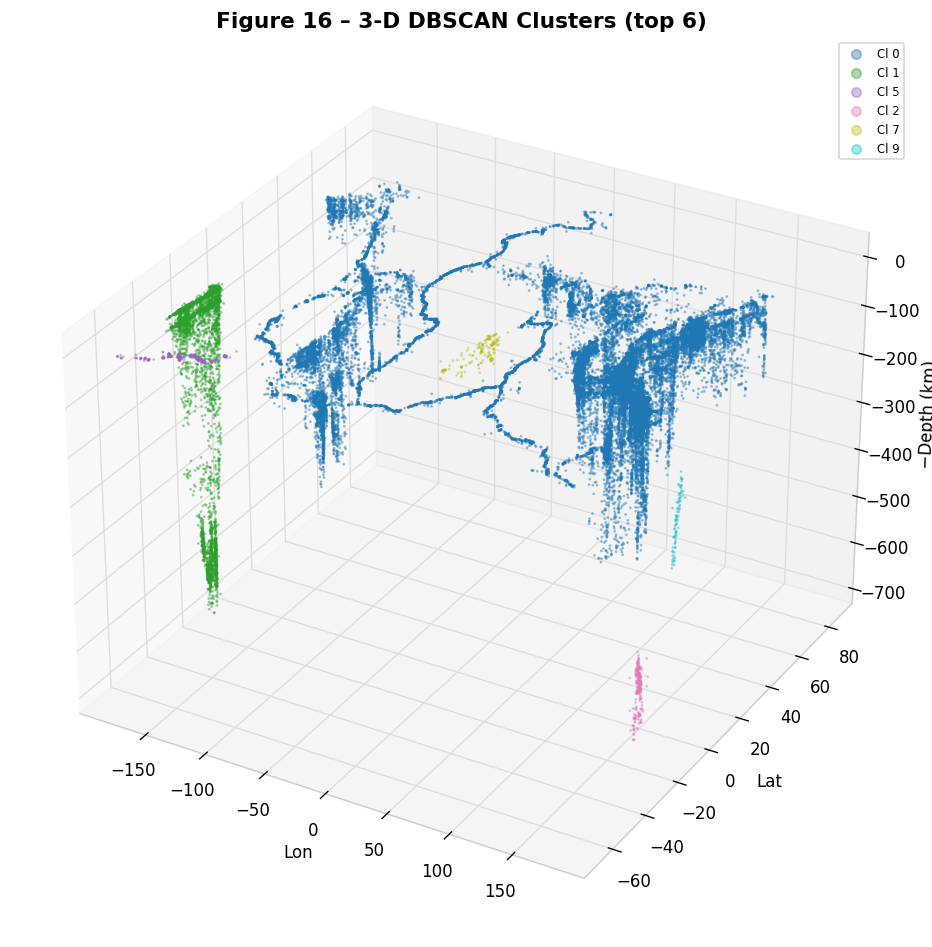

In [24]:

# VIZ 16 – 3-D DBSCAN Cluster View (lat, lon, depth)
from mpl_toolkits.mplot3d import Axes3D

top_cl_ids = samp[samp['dbscan_label'] != -1]['dbscan_label'].value_counts().head(6).index.tolist()
fig = plt.figure(figsize=(14,8))
ax3d = fig.add_subplot(111, projection='3d')
cmap3 = plt.cm.get_cmap('tab10', 6)
for ki, cl in enumerate(top_cl_ids):
    sub3 = samp[samp['dbscan_label'] == cl]
    ax3d.scatter(sub3['longitude'], sub3['latitude'], -sub3['depth'],
                 c=[cmap3(ki)], s=0.5, alpha=0.4, label=f'Cl {cl}')
ax3d.set_xlabel('Lon'); ax3d.set_ylabel('Lat'); ax3d.set_zlabel('−Depth (km)')
ax3d.set_title('Figure 16 – 3-D DBSCAN Clusters (top 6)')
ax3d.legend(markerscale=8, fontsize=7)
plt.tight_layout()
plt.savefig('spatial_data_mining/fig16_3d_dbscan.png', dpi=150, bbox_inches='tight')
plt.show()


In [26]:

print("=" * 60)
print("SPATIAL DATA MINING SUMMARY")
print("=" * 60)
print(f"DBSCAN clusters found     : {n_clusters}")
print(f"Noise points              : {n_noise}")
print(f"Spatial outliers (|Zs|>2) : {len(outliers)}")
print(f"Moran's I (Magnitude)     : {I:.4f}")
print(f"Ripley K > CSR            : {(K_obs > K_csr).sum()} / {len(radii)} radii")
print(f"NNA R-statistic           : {R:.3f} (< 1 ⟹ Clustered)")
print(f"Collocation P(Shallow|HiMag): {pr_HiMag_Shallow:.3f}")
print(f"Collocation P(VDeep|HiMag)  : {pr_HiMag_VDeep:.3f}")
print("=" * 60)


SPATIAL DATA MINING SUMMARY
DBSCAN clusters found     : 22
Noise points              : 591
Spatial outliers (|Zs|>2) : 2996
Moran's I (Magnitude)     : 0.0444
Ripley K > CSR            : 20 / 20 radii
NNA R-statistic           : 0.331 (< 1 ⟹ Clustered)
Collocation P(Shallow|HiMag): 0.958
Collocation P(VDeep|HiMag)  : 0.198
